# 02 – Two-Stage Training U-Net: Crack Detection

**CSE445 – Road Surface Crack Detection & Segmentation**

This notebook implements **Two-Stage Fine-Tuning** to solve severe class imbalance and thin crack scale problems:
- **Stage 1**: Pre-train U-Net on high-contrast Close-Up crack dataset (`stage1_train.csv`).
- **Stage 2**: Transfer weights and fine-tune on Dashcam / Drone survey dataset (`train.csv`) at a lower learning rate (`3e-5`) with 90% Dice loss.

In [1]:
%load_ext autoreload
%autoreload 2
import sys, os
os.environ['NO_ALBUMENTATIONS_UPDATE'] = '1'
try:
    from google.colab import drive
    drive.mount('/content/drive')
    REPO = '/content/drive/MyDrive/Road_Damage_Project'
    os.environ['RUN_ENV'] = 'colab'
except ImportError:
    REPO = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
    os.environ['RUN_ENV'] = 'local'

if REPO not in sys.path:
    sys.path.insert(0, REPO)
print('Repo root:', REPO)

Repo root: d:\Road_Damage_Project


In [2]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

import config
from support.shared.dataset import SegmentationDataset
from support.shared.transforms import get_train_transforms, get_val_transforms
from support.shared.unet import UNet
from support.shared.losses import BCEDiceLoss
from support.shared.trainer import Trainer

print('PyTorch version:', torch.__version__)
print('CUDA available :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU            :', torch.cuda.get_device_name(0))

d:\anaconda3\envs\Thesis\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.10.0+cu130
CUDA available : True
GPU            : NVIDIA GeForce RTX 5070 Ti


---
## 1. Stage 1: Pre-training on Close-Up Dataset
Here we train U-Net on high-contrast, macro crack images to learn clear asphalt textures and crack fissures.

In [3]:
cfg_s1 = config.CRACK_UNET_STAGE1
img_size = (config.IMG_HEIGHT, config.IMG_WIDTH)

# Manifest paths
s1_train_csv = config.CRACK_SPLIT_DIR / 'stage1_train.csv'
s1_val_csv   = config.CRACK_SPLIT_DIR / 'stage1_val.csv'
if not s1_train_csv.exists():
    s1_train_csv = config.CRACK_SPLIT_DIR / 'closeup_train.csv'
    s1_val_csv   = config.CRACK_SPLIT_DIR / 'closeup_val.csv'

train_ds_s1 = SegmentationDataset(s1_train_csv, transform=get_train_transforms(img_size))
val_ds_s1   = SegmentationDataset(s1_val_csv,   transform=get_val_transforms(img_size))

train_loader_s1 = DataLoader(train_ds_s1, batch_size=cfg_s1['batch_size'], shuffle=True,  num_workers=4, pin_memory=True)
val_loader_s1   = DataLoader(val_ds_s1,   batch_size=cfg_s1['batch_size'], shuffle=False, num_workers=4, pin_memory=True)

print(f'Stage 1 Train: {len(train_ds_s1)} samples, {len(train_loader_s1)} batches')
print(f'Stage 1 Val  : {len(val_ds_s1)} samples, {len(val_loader_s1)} batches')

Stage 1 Train: 2346 samples, 74 batches
Stage 1 Val  : 502 samples, 16 batches


In [4]:
# Build Stage 1 Model & Loss
model_s1 = UNet(in_channels=cfg_s1['in_channels'], out_channels=cfg_s1['out_channels'], base_features=cfg_s1['base_features'])
loss_fn_s1 = BCEDiceLoss(bce_weight=cfg_s1['bce_weight'], dice_weight=cfg_s1['dice_weight'])
trainer_s1 = Trainer(model_s1, loss_fn_s1, cfg_s1, train_loader_s1, val_loader_s1)

# Train Stage 1 (set n_epochs=None to use config epochs, or e.g. n_epochs=3 for quick testing)
history_s1 = trainer_s1.fit(n_epochs=None)
print('Stage 1 Best Checkpoint:', trainer_s1.best_model_path)

[Trainer] Using device: cuda
[Trainer] Mixed precision (AMP) enabled.
[Trainer] Config snapshot -> D:\Road_Damage_Project\experiments\crack_stage1_unet\config_snapshot.json

  Starting training: crack_stage1_unet
  Epochs: 40   Device: cuda   LR: 0.0002
  Early stopping patience: 8
  Output dir: D:\Road_Damage_Project\experiments\crack_stage1_unet

  Ep       LR |   TrLoss   TrIoU |   VaLoss   VaIoU  VaDice |  Best?
--------------------------------------------------------------------


   1 2.00e-04 |   0.7075  0.3391 |   0.6693  0.3640  0.5104 |  * NEW


   2 2.00e-04 |   0.6485  0.3922 |   0.6295  0.3921  0.5370 |  * NEW


   3 2.00e-04 |   0.6120  0.4180 |   0.5909  0.4442  0.5910 |  * NEW


   4 2.00e-04 |   0.5719  0.4415 |   0.5593  0.4284  0.5716 |       


...

  11 2.00e-04 |   0.6706  0.2589 |   0.6038  0.2987  0.4292 |       


  12 2.00e-04 |   0.6721  0.2593 |   0.6052  0.2982  0.4290 |       


  13 1.00e-04 |   0.6786  0.2592 |   0.6089  0.3021  0.4341 |       


  14 1.00e-04 |   0.6764  0.2562 |   0.6215  0.2986  0.4304 |       


  15 1.00e-04 |   0.6762  0.2619 |   0.6322  0.2955  0.4279 |       

[Trainer] Early stopping at epoch 15 (no improvement for 8 epochs).

[Trainer] Training complete. Best val IoU: 0.5118
[Trainer] Best checkpoint -> D:\Road_Damage_Project\experiments\crack_stage1_unet\best_model.pth
[Trainer] Training log    -> D:\Road_Damage_Project\experiments\crack_stage1_unet\train_log.csv

Stage 1 Best Checkpoint: D:\Road_Damage_Project\experiments\crack_stage1_unet\best_model.pth


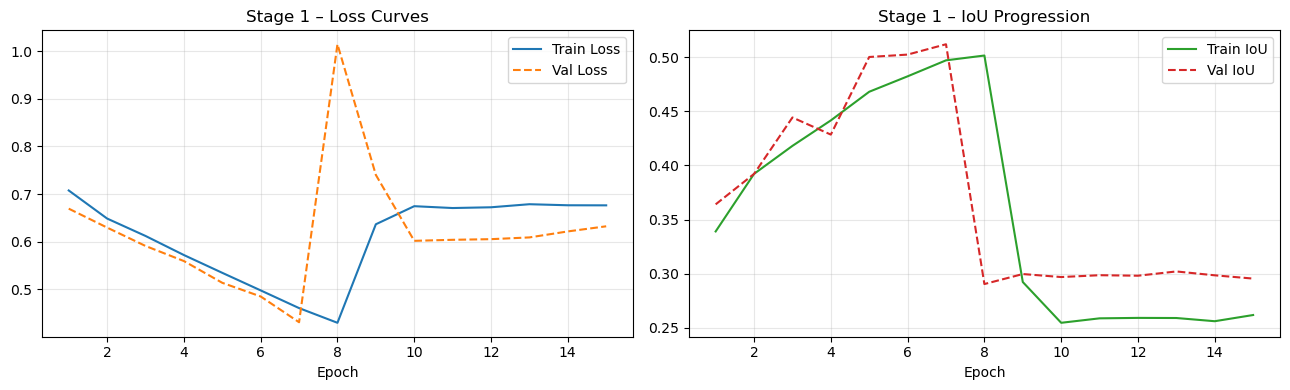

In [5]:
# Plot Stage 1 Learning Curves
df_s1 = pd.DataFrame(history_s1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(df_s1['epoch'], df_s1['train_loss'], label='Train Loss', color='tab:blue')
axes[0].plot(df_s1['epoch'], df_s1['val_loss'],   label='Val Loss',   color='tab:orange', linestyle='--')
axes[0].set_title('Stage 1 – Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_s1['epoch'], df_s1['train_iou'], label='Train IoU', color='tab:green')
axes[1].plot(df_s1['epoch'], df_s1['val_iou'],   label='Val IoU',   color='tab:red', linestyle='--')
axes[1].set_title('Stage 1 – IoU Progression')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 2. Stage 2: Fine-Tuning on Dashcam / Drone Dataset
We load the Stage 1 trained weights into U-Net and fine-tune on the dashcam dataset using a reduced learning rate (`3e-5`) and 90% Dice loss.

In [3]:
cfg_s2 = config.CRACK_UNET_STAGE2
img_size = (config.IMG_HEIGHT, config.IMG_WIDTH)

# Dashcam Split manifests
s2_train_csv = config.CRACK_SPLIT_DIR / 'train.csv'
s2_val_csv   = config.CRACK_SPLIT_DIR / 'val.csv'
if not s2_train_csv.exists():
    s2_train_csv = config.CRACK_SPLIT_DIR / 'dashcam_train.csv'
    s2_val_csv   = config.CRACK_SPLIT_DIR / 'dashcam_val.csv'

train_ds_s2 = SegmentationDataset(s2_train_csv, transform=get_train_transforms(img_size))
val_ds_s2   = SegmentationDataset(s2_val_csv,   transform=get_val_transforms(img_size))

train_loader_s2 = DataLoader(train_ds_s2, batch_size=cfg_s2['batch_size'], shuffle=True,  num_workers=8, pin_memory=True,persistent_workers=True)
val_loader_s2   = DataLoader(val_ds_s2,   batch_size=cfg_s2['batch_size'], shuffle=False, num_workers=8, pin_memory=True,persistent_workers=True)

print(f'Stage 2 Train: {len(train_ds_s2)} samples, {len(train_loader_s2)} batches')
print(f'Stage 2 Val  : {len(val_ds_s2)} samples, {len(val_loader_s2)} batches')

Stage 2 Train: 1982 samples, 62 batches
Stage 2 Val  : 424 samples, 14 batches


In [4]:
# Build Stage 2 Model and Configure Extended Training (Total 75 Epochs)
cfg_s2 = config.CRACK_UNET_STAGE2.copy()
cfg_s2["epochs"] = 75

model_s2 = UNet(in_channels=cfg_s2["in_channels"], out_channels=cfg_s2["out_channels"], base_features=cfg_s2["base_features"])

# Check if resuming from existing Stage 2 checkpoint or starting fresh from Stage 1
stage2_ckpt = config.EXP_DIR / "crack_stage2_unet_finetuned" / "best_model.pth"
stage1_ckpt = config.EXP_DIR / "crack_stage1_unet" / "best_model.pth"

if stage2_ckpt.exists():
    print(f"Found Stage 2 checkpoint: {stage2_ckpt}")
    print("Resuming Stage 2 training up to 75 total epochs...")
    cfg_s2["resume_checkpoint"] = stage2_ckpt
elif stage1_ckpt.exists():
    print(f"Transferring Stage 1 weights from: {stage1_ckpt}")
    state = torch.load(stage1_ckpt, map_location="cpu")
    if isinstance(state, dict) and "model_state_dict" in state:
        state = state["model_state_dict"]
    model_s2.load_state_dict(state)
    print("[OK] Stage 1 weights transferred successfully!")

loss_fn_s2 = BCEDiceLoss(bce_weight=cfg_s2["bce_weight"], dice_weight=cfg_s2["dice_weight"])
trainer_s2 = Trainer(model_s2, loss_fn_s2, cfg_s2, train_loader_s2, val_loader_s2)

# Fine-tune Stage 2
history_s2 = trainer_s2.fit()
print("Stage 2 Final Checkpoint:", trainer_s2.best_model_path)


Found Stage 2 checkpoint: D:\Road_Damage_Project\experiments\crack_stage2_unet_finetuned\best_model.pth
Resuming Stage 2 training up to 75 total epochs...
[Trainer] Using device: cuda
[Trainer] Mixed precision (AMP) enabled.
[Trainer] Resuming from checkpoint: D:\Road_Damage_Project\experiments\crack_stage2_unet_finetuned\best_model.pth
[Trainer] Resumed model state. Baseline best Val IoU: 0.1910, Start epoch: 67
[Trainer] Config snapshot -> D:\Road_Damage_Project\experiments\crack_stage2_unet_finetuned\config_snapshot.json

  Starting training: crack_stage2_unet_finetuned
  Epochs: 67 to 75 (Total: 75) | Device: cuda | Initial LR: 1.00e-04
  Early stopping patience: 12
  Output dir: D:\Road_Damage_Project\experiments\crack_stage2_unet_finetuned

  Ep       LR |   TrLoss   TrIoU |   VaLoss   VaIoU  VaDice |  Best?
--------------------------------------------------------------------


  67 1.00e-04 |   0.3952  0.1636 |   0.3784  0.1849  0.2772 |       


  68 1.00e-04 |   0.3951  0.1632 |   0.3747  0.1907  0.2849 |       


  69 1.00e-04 |   0.3945  0.1647 |   0.3748  0.1912  0.2853 |  * NEW


  70 1.00e-04 |   0.3864  0.1760 |   0.3750  0.1912  0.2860 |       


  71 1.00e-04 |   0.3855  0.1772 |   0.3750  0.1901  0.2839 |       


  72 1.00e-04 |   0.3840  0.1795 |   0.3763  0.1887  0.2814 |       


  73 1.00e-04 |   0.3851  0.1778 |   0.3726  0.1930  0.2881 |  * NEW


  74 1.00e-04 |   0.3877  0.1736 |   0.3744  0.1914  0.2842 |       


  75 1.00e-04 |   0.3844  0.1779 |   0.3788  0.1855  0.2756 |       

[Trainer] Training complete. Best val IoU: 0.1930
[Trainer] Best checkpoint -> D:\Road_Damage_Project\experiments\crack_stage2_unet_finetuned\best_model.pth
[Trainer] Training log    -> D:\Road_Damage_Project\experiments\crack_stage2_unet_finetuned\train_log.csv

Stage 2 Final Checkpoint: D:\Road_Damage_Project\experiments\crack_stage2_unet_finetuned\best_model.pth


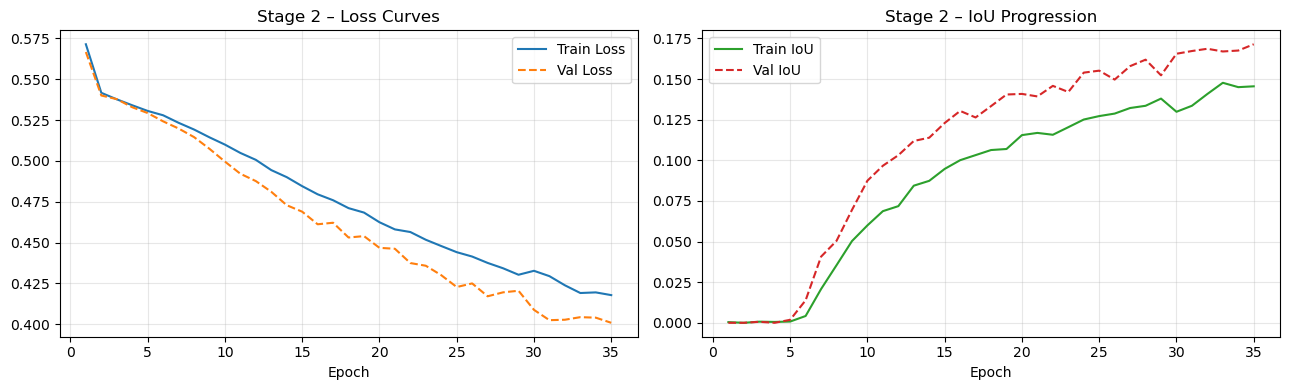

In [7]:
# Plot Stage 2 Fine-Tuning Curves
log_path = config.EXP_DIR / "crack_stage2_unet_finetuned" / "train_log.csv"
if log_path.exists():
    df_s2 = pd.read_csv(log_path)
elif "history_s2" in locals():
    df_s2 = pd.DataFrame(history_s2)
else:
    df_s2 = None

if df_s2 is not None and not df_s2.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(df_s2["epoch"], df_s2["train_loss"], label="Train Loss", color="tab:blue")
    axes[0].plot(df_s2["epoch"], df_s2["val_loss"],   label="Val Loss",   color="tab:orange", linestyle="--")
    axes[0].set_title("Stage 2 – Loss Curves")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(df_s2["epoch"], df_s2["train_iou"], label="Train IoU", color="tab:green")
    axes[1].plot(df_s2["epoch"], df_s2["val_iou"],   label="Val IoU",   color="tab:red", linestyle="--")
    axes[1].plot(df_s2["epoch"], df_s2["val_dice"],  label="Val Dice",  color="tab:purple", linestyle=":")
    axes[1].set_title("Stage 2 – IoU Progression")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
